In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
data = pd.read_csv(r'C:\Users\MY LOQ\OneDrive\Desktop\Data_Science\telco-customer-churn\data\Telco-Customer-Churn.csv')
data.drop('customerID', axis=1, inplace=True)
data.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [4]:
data.shape

(7043, 20)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [6]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
data['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [10]:
data = data.dropna()

In [11]:
data.shape

(7032, 20)

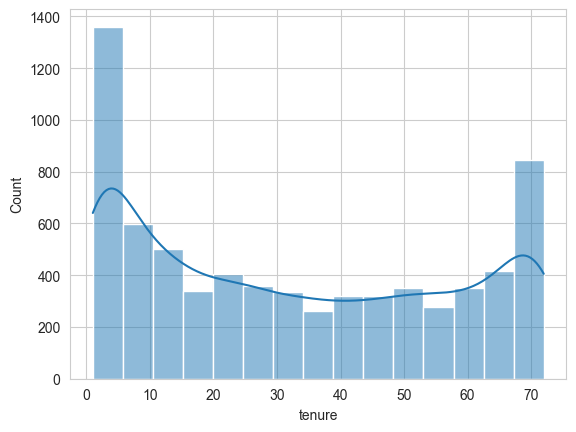

In [12]:
sns.histplot(data["tenure"], kde=True)
plt.show()

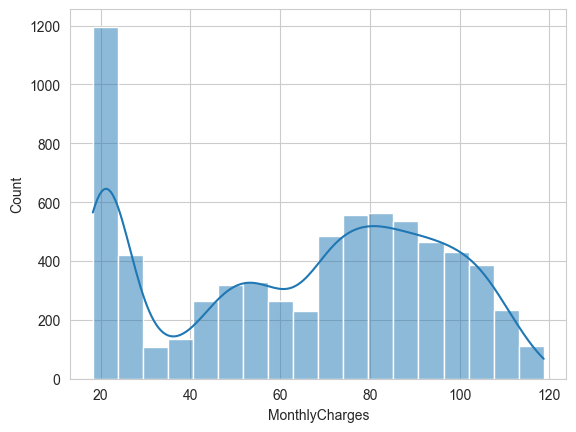

In [13]:
sns.histplot(data['MonthlyCharges'], kde=True)
plt.show()

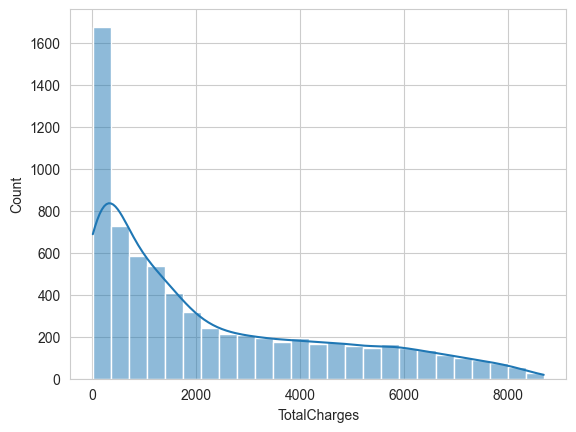

In [14]:
sns.histplot(data['TotalCharges'], kde=True)
plt.show()

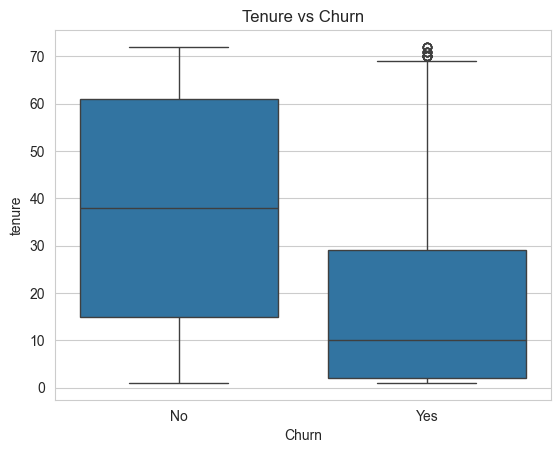

In [15]:
sns.boxplot(x='Churn', y='tenure', data=data)
plt.title('Tenure vs Churn')
plt.show()

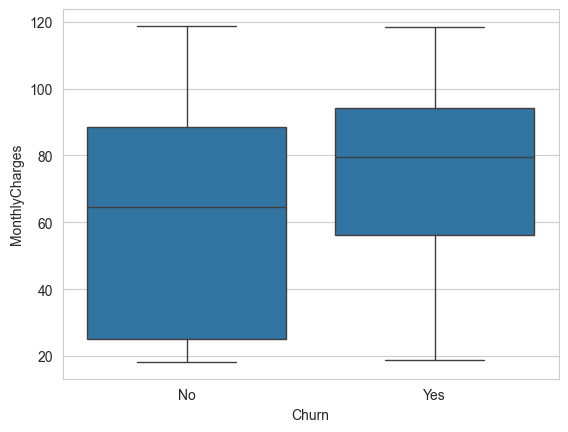

In [16]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=data)
plt.show()

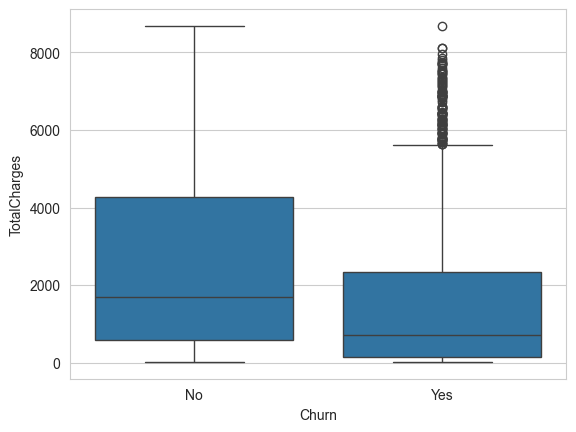

In [17]:
sns.boxplot(x='Churn', y='TotalCharges', data=data)
plt.show()

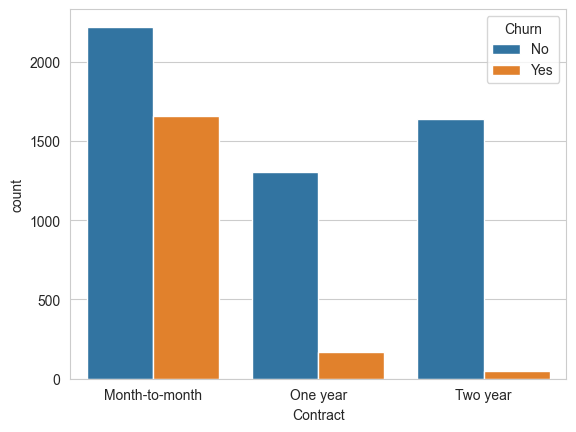

In [18]:
sns.countplot(x="Contract", hue='Churn', data=data)
plt.show()

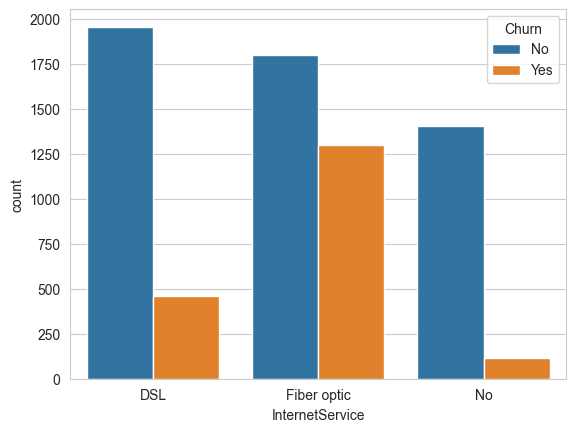

In [19]:
sns.countplot(x='InternetService', hue='Churn', data=data)
plt.show()

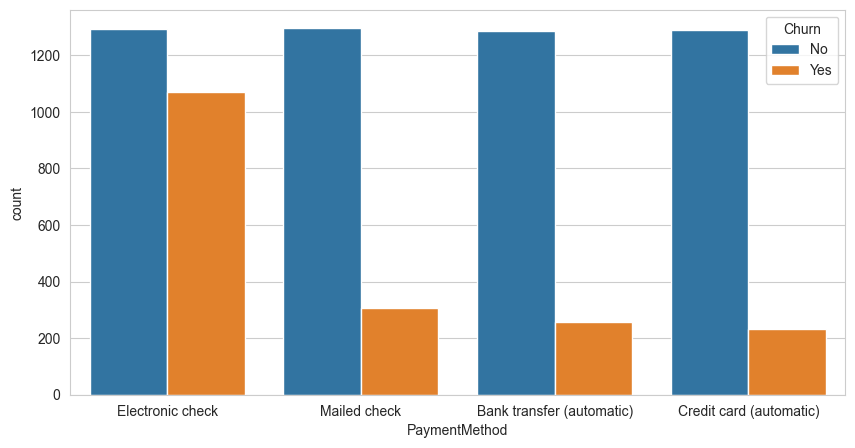

In [20]:
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=data)
plt.show()

In [21]:
num_col = data.select_dtypes(include=['int64', 'float64'])
corr = num_col.corr()

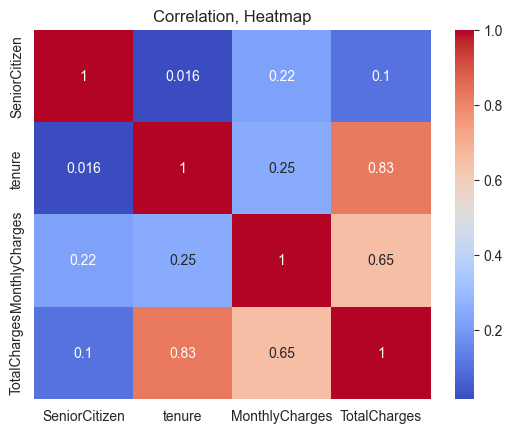

In [22]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation, Heatmap")
plt.show()

In [23]:
data["Churn"] = data["Churn"].map({"Yes":1,"No":0})

In [24]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [25]:
x = data.drop('Churn', axis=1)
y = data['Churn']

In [26]:
num_cols = x.select_dtypes(include=['number']).columns
cat_cols = x.select_dtypes(include=['object']).columns

In [27]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [30]:
from sklearn.linear_model import LogisticRegression
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(class_weight="balanced" ))
])

lr_pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
lr_pipeline.score(x_train, y_train)*100, lr_pipeline.score(x_test, y_test)*100

(75.48444444444445, 73.20540156361052)

In [32]:
y_pred = lr_pipeline.predict(x_test)

In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7320540156361052
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407

[[734 299]
 [ 78 296]]


In [34]:
from sklearn.ensemble import RandomForestClassifier
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_estimators=200, class_weight="balanced"))
])

rf_pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [35]:
rf_pipeline.score(x_train, y_train)*100, rf_pipeline.score(x_test, y_test)*100

(99.76888888888888, 78.1094527363184)

In [36]:
y_pred_rf = rf_pipeline.predict(x_test)

In [37]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7810945273631841
[[931 102]
 [206 168]]
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.62      0.45      0.52       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



In [38]:
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier())
])

gb_pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [39]:
y_pred_gb = gb_pipeline.predict(x_test)

In [40]:
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Accuracy: 0.7889125799573561
[[923 110]
 [187 187]]
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [41]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1000, class_weight="balanced")),
        ("rf", RandomForestClassifier(random_state=42, n_estimators=200, class_weight="balanced")),
        ("gb", GradientBoostingClassifier())
    ],
    voting="hard"
)

In [42]:
voting_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", voting_model)
])

voting_pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:
voting_pipeline.score(x_train, y_train)*100, voting_pipeline.score(x_test, y_test)*100

(88.96, 78.3226723525231)

In [44]:
y_pred_vote = voting_pipeline.predict(x_test)

In [45]:
print("Accuracy:", accuracy_score(y_test, y_pred_vote))
print(confusion_matrix(y_test, y_pred_vote))
print(classification_report(y_test, y_pred_vote))

Accuracy: 0.783226723525231
[[900 133]
 [172 202]]
              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1033
           1       0.60      0.54      0.57       374

    accuracy                           0.78      1407
   macro avg       0.72      0.71      0.71      1407
weighted avg       0.78      0.78      0.78      1407



In [46]:
rf_model = rf_pipeline.named_steps['model']
importances = rf_model.feature_importances_

In [47]:
feature_names = preprocessor.get_feature_names_out()

In [48]:
feat_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feat_importance = feat_importance.sort_values(by="importance", ascending=False)
top_feature = feat_importance.head(10)

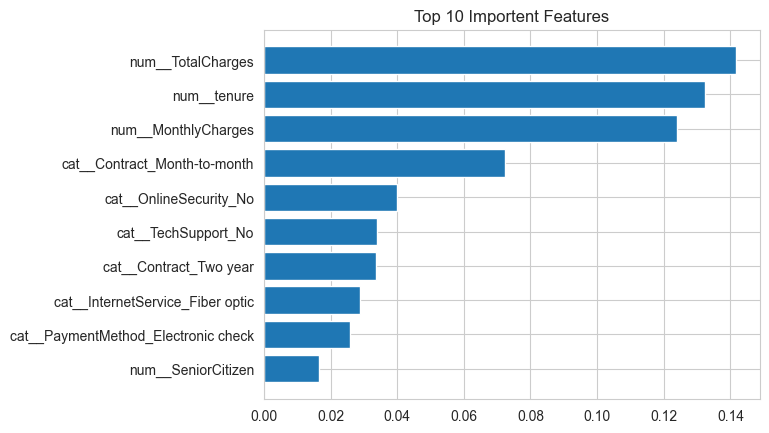

In [49]:
plt.barh(top_feature['feature'], top_feature['importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Importent Features")
plt.show()

In [50]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
     "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"]
}

grid_lr = GridSearchCV(
    lr_pipeline,
    param_grid_lr,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

grid_lr.fit(x_train, y_train)

best_lr = grid_lr.best_estimator_
print(grid_lr.best_params_)

{'model__C': 1, 'model__solver': 'liblinear'}


In [51]:
y_pred = best_lr.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7313432835820896
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



In [52]:
import joblib 
joblib.dump(best_lr, "churn_model.pkl")

['churn_model.pkl']

In [53]:
x_test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
2481,Male,1,Yes,No,61,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),25.00,1501.75
6784,Female,0,No,No,19,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),24.70,465.85
6125,Male,0,Yes,No,13,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),102.25,1359.00
3052,Male,0,Yes,No,37,Yes,Yes,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Mailed check,55.05,2030.75
4099,Female,0,No,No,6,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Bank transfer (automatic),29.45,161.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1733,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.05,19.05
5250,Male,0,No,No,12,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,94.55,1173.55
5465,Female,0,No,No,26,Yes,No,DSL,No,Yes,Yes,No,No,No,One year,Yes,Mailed check,56.05,1553.20
5851,Female,1,No,No,35,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,One year,Yes,Bank transfer (automatic),110.80,3836.30
